<a href="https://colab.research.google.com/github/amathie5/projet-breast-cancer/blob/main/datascience_project_breastcancer_v10_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
#CSV files importation
df1 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df1.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df2.csv')
df3 = pd.read_csv('https://raw.githubusercontent.com/amathie5/projet-breast-cancer/refs/heads/main/df3.csv')

#Concatening all dataframes together to be left with one unique dataframe
df = pd.concat([df1,df2,df3]).sort_values(by='year')
df_encoded = df.copy()

#Displaying the head of the dataset
display(df.head())

# Number of variables (columns)
num_variables = df.shape[1]

# Number of observations (lines)
num_observations = df.shape[0]

# Total number of values
total_values = df.size  # équivalent à num_variables * num_observations

# Affichage
print(f'The dataset contains a total of {num_variables} variables and {num_observations} observations, for a total of {total_values} values')
print(f'The dataset contains no null value and every variable is of type int64')

##variables description
missing = df_encoded.isnull().sum()
types = df_encoded.dtypes.astype(str)

# Descriptions dictionary
descriptions = {
    "year": "Year of mammogram (2005–2017)",
    "age_group_5_years": "Age in 5-year intervals",
    "race_eth": "Race/ethnicity",
    "bmi_group": "BMI categories",
    "menopaus": "Menopausal status (pre-, post-, surgical)",
    "current_hrt": "Current hormone replacement therapy use",
    "first_degree_hx": "Family history of breast cancer",
    "age_menarche": "Age at first menstruation",
    "age_first_birth": "Age at first birth",
    "BIRADS_breast_density": "BI-RADS breast density classification (1–4)",
    "breast_cancer_history": "Prior breast cancer diagnosis (yes/no)",
    "count": "Number of women in this profile",
}

# Summary table
summary = (
    pd.DataFrame({
        "Variable": types.index,
        "Type": types.values,
        "Missing": missing.values,
    })
    .assign(
        Missing_pct=lambda d: (d["Missing"] / len(df_encoded)).round(4),
        Description=lambda d: d["Variable"].map(descriptions)
    )
    .loc[:, ["Variable", "Type", "Missing", "Missing_pct", "Description"]]
)
summary


,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,1,1,0,1,0,2,0,1,1,0,0,1
19,2005,1,1,0,0,9,4,0,1,9,9,9,1
18,2005,1,1,0,0,9,4,0,1,1,0,0,1
7,2005,1,1,0,0,4,2,0,1,1,0,0,1
6,2005,1,1,0,0,2,3,0,1,9,0,0,1


The dataset contains a total of 13 variables and 1522340 observations, for a total of 19790420 values
The dataset contains no null value and every variable is of type int64


,Variable,Type,Missing,Missing_pct,Description
0,year,int64,0,0.0,Year of mammogram (2005–2017)
1,age_group_5_years,int64,0,0.0,Age in 5-year intervals
2,race_eth,int64,0,0.0,Race/ethnicity
3,first_degree_hx,int64,0,0.0,Family history of breast cancer
4,age_menarche,int64,0,0.0,Age at first menstruation
5,age_first_birth,int64,0,0.0,Age at first birth
6,BIRADS_breast_density,int64,0,0.0,BI-RADS breast density classification (1–4)
7,current_hrt,int64,0,0.0,Current hormone replacement therapy use
8,menopaus,int64,0,0.0,"Menopausal status (pre-, post-, surgical)"
9,bmi_group,int64,0,0.0,BMI categories


In [ ]:
age_map = {1:'18-29',2:'30-34',3:'35-39',4:'40-44',5:'45-49',6:'50-54',7:'55-59',8:'60-64',9:'65-69',10:'70-74',11:'75-79',12:'80-84',13:'85+'}
race_map = {1:'non-hispanic white', 2:'non-hispanic black', 3:'asian/pacific islander', 4:'native american',5:'hispanic',6:'other/mixed',9:'unknown'}
familyhx_map = {0:'no', 1:'yes', 9:'unknown'}
menarche_map = {0:'14+',1:'12-13',2:'<12',9:'unknown'}
firstbirth_map = {0:'<20',1:'20-24',2:'25-29',3:'30+',4:'nulliparous',9:'unknown'}
BIRADS_map = {1:'fatty',2:'scattered',3:'heterogeneously dense', 4:'extremely dense', 5:'unknown'}
hrt_map = {0:'no', 1:'yes',9:'unknown'}
menopaus_map = {1:'pre-menopausal',2:'post-menopausal',3:'surgical menopause', 9:'unknown'}
bmi_map = {1:'10-24.99',2:'25-29.99',3:'30-34.99',4:'35+',9:'unknown'}
biophx_map = {0:'no',1:'yes', 9:'unknown'}
history_map = {0:'no',1:'yes',9:'unknown'}

#Replacing the code with the categories
df['age_group_5_years']=df['age_group_5_years'].map(age_map)
df['race_eth']=df['race_eth'].map(race_map)
df['first_degree_hx']=df['first_degree_hx'].map(familyhx_map)
df['age_menarche']=df['age_menarche'].map(menarche_map)
df['age_first_birth']=df['age_first_birth'].map(firstbirth_map)
df['BIRADS_breast_density']=df['BIRADS_breast_density'].map(BIRADS_map)
df['current_hrt']=df['current_hrt'].map(hrt_map)
df['menopaus']=df['menopaus'].map(menopaus_map)
df['bmi_group']=df['bmi_group'].map(bmi_map)
df['biophx']=df['biophx'].map(biophx_map)
df['breast_cancer_history']=df['breast_cancer_history'].map(history_map)

#convert as category
cat_cols = ['age_group_5_years','race_eth','first_degree_hx','age_menarche','age_first_birth','BIRADS_breast_density','current_hrt','menopaus','bmi_group','biophx','breast_cancer_history']
df[cat_cols] = df[cat_cols].astype('category')
display(df.head())
df.info()
df.isna().sum()




,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1
19,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,unknown,unknown,unknown,1
18,2005,18-29,non-hispanic white,no,14+,unknown,extremely dense,no,pre-menopausal,10-24.99,no,no,1
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,unknown,no,no,1


<class 'pandas.core.frame.DataFrame'>
Index: 1522340 entries, 20 to 411300
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   year                   1522340 non-null  int64   
 1   age_group_5_years      1522340 non-null  category
 2   race_eth               1522340 non-null  category
 3   first_degree_hx        1522340 non-null  category
 4   age_menarche           1522340 non-null  category
 5   age_first_birth        1522340 non-null  category
 6   BIRADS_breast_density  1343329 non-null  category
 7   current_hrt            1522340 non-null  category
 8   menopaus               1522340 non-null  category
 9   bmi_group              1522340 non-null  category
 10  biophx                 1522340 non-null  category
 11  breast_cancer_history  1522340 non-null  category
 12  count                  1522340 non-null  int64   
dtypes: category(11), int64(2)
memory usage: 50.8 MB


,0
year,0
age_group_5_years,0
race_eth,0
first_degree_hx,0
age_menarche,0
age_first_birth,0
BIRADS_breast_density,179011
current_hrt,0
menopaus,0
bmi_group,0


In [ ]:
#replace unknown values by nan
df = df.replace('unknown',np.nan)

#check for duplicates
print(df.duplicated().sum())

#the total number of observations should be 6'788'436
print(df['count'].sum())


/tmp/ipython-input-3569221684.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df = df.replace('unknown',np.nan)


0
6788436


In [ ]:
#create two binary variables for high BIRADS and cancer history
df['BIRADS_high']=np.where(df_encoded['BIRADS_breast_density'].isin([3,4]),1,0)
df['breast_cancer_history_bin']=np.where(df_encoded['breast_cancer_history']==1,1,0)

#check the distribution
display(df['BIRADS_high'])
display(df['breast_cancer_history_bin'])

display(df.head())

,BIRADS_high
20,0
19,1
18,1
7,0
6,1
...,...
411304,1
411303,1
411302,1
411301,1


,breast_cancer_history_bin
20,0
19,0
18,0
7,0
6,0
...,...
411304,0
411303,0
411302,0
411301,0


,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
20,2005,18-29,non-hispanic white,no,12-13,<20,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
19,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,NaN,NaN,NaN,1,1,0
18,2005,18-29,non-hispanic white,no,14+,NaN,extremely dense,no,pre-menopausal,10-24.99,no,no,1,1,0
7,2005,18-29,non-hispanic white,no,14+,nulliparous,scattered,no,pre-menopausal,10-24.99,no,no,1,0,0
6,2005,18-29,non-hispanic white,no,14+,25-29,heterogeneously dense,no,pre-menopausal,NaN,no,no,1,1,0


In [ ]:
#check types and unique values
for col in cat_cols:
  print(col, ':',df[col].unique())

age_group_5_years : ['18-29', '85+', '30-34', '35-39', '40-44', ..., '60-64', '65-69', '70-74', '75-79', '80-84']
Length: 13
Categories (13, object): ['18-29', '30-34', '35-39', '40-44', ..., '70-74', '75-79', '80-84', '85+']
race_eth : ['non-hispanic white', NaN, 'non-hispanic black', 'asian/pacific islander', 'hispanic', 'native american', 'other/mixed']
Categories (6, object): ['asian/pacific islander', 'hispanic', 'native american', 'non-hispanic black',
                         'non-hispanic white', 'other/mixed']
first_degree_hx : ['no', NaN, 'yes']
Categories (2, object): ['no', 'yes']
age_menarche : ['12-13', '14+', NaN, '<12']
Categories (3, object): ['12-13', '14+', '<12']
age_first_birth : ['<20', NaN, 'nulliparous', '25-29', '20-24', '30+']
Categories (5, object): ['20-24', '25-29', '30+', '<20', 'nulliparous']
BIRADS_breast_density : ['scattered', 'extremely dense', 'heterogeneously dense', NaN, 'fatty']
Categories (4, object): ['extremely dense', 'fatty', 'heterogeneously

In [ ]:
df_cleaned = df.dropna()
#count of non-null variables
non_null_cleaned = df_cleaned.notna().sum()

#Number of missing values
missing_cleaned = df_cleaned.isna().sum()

#variables type
dtypes_cleaned = df_cleaned.dtypes.astype(str)

#Building the table
summary_cleaned = (
    pd.DataFrame({
        "Variable": df_cleaned.columns,
        "Non-null values": non_null_cleaned.values,
        "Missing values": missing_cleaned.values,
        "Missing %": (missing_cleaned/len(df_cleaned)).fillna(0).map(lambda x: f"{x:.0%}"),
        "Type": dtypes_cleaned.values,
    })
)
summary_cleaned

,Variable,Non-null values,Missing values,Missing %,Type
year,year,345064,0,0%,int64
age_group_5_years,age_group_5_years,345064,0,0%,category
race_eth,race_eth,345064,0,0%,category
first_degree_hx,first_degree_hx,345064,0,0%,category
age_menarche,age_menarche,345064,0,0%,category
age_first_birth,age_first_birth,345064,0,0%,category
BIRADS_breast_density,BIRADS_breast_density,345064,0,0%,category
current_hrt,current_hrt,345064,0,0%,category
menopaus,menopaus,345064,0,0%,category
bmi_group,bmi_group,345064,0,0%,category


In [ ]:

df_cleaned_descr = df_cleaned.describe(include = 'all')
df_cleaned_descr['year'] = df_cleaned_descr['year'].round(0)
display(df_cleaned_descr)

,year,age_group_5_years,race_eth,first_degree_hx,age_menarche,age_first_birth,BIRADS_breast_density,current_hrt,menopaus,bmi_group,biophx,breast_cancer_history,count,BIRADS_high,breast_cancer_history_bin
count,345064.0,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064,345064.000000,345064.000000,345064.000000
unique,NaN,13,6,2,3,5,4,2,3,4,2,2,NaN,NaN,NaN
top,NaN,50-54,non-hispanic white,no,12-13,20-24,scattered,no,post-menopausal,10-24.99,no,no,NaN,NaN,NaN
freq,NaN,55940,160707,244775,146835,80181,128616,324839,203441,105624,211903,292132,NaN,NaN,NaN
mean,2011.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.024227,0.491874,0.153398
std,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.468720,0.499935,0.360371
min,2005.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
25%,2008.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
50%,2012.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000
75%,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,1.000000,0.000000


Certaines combinaisons reviennent très fréquemment (1093 fois) alors que certains ne sont présente que une fois. En moyenne les combinaisons apparaissent 5,5 fois.
En moyenne 47,75% des femmes ont une densité mammaire élevée et 16,42% ont été diagnostiquées avec un cancer dans le passé.

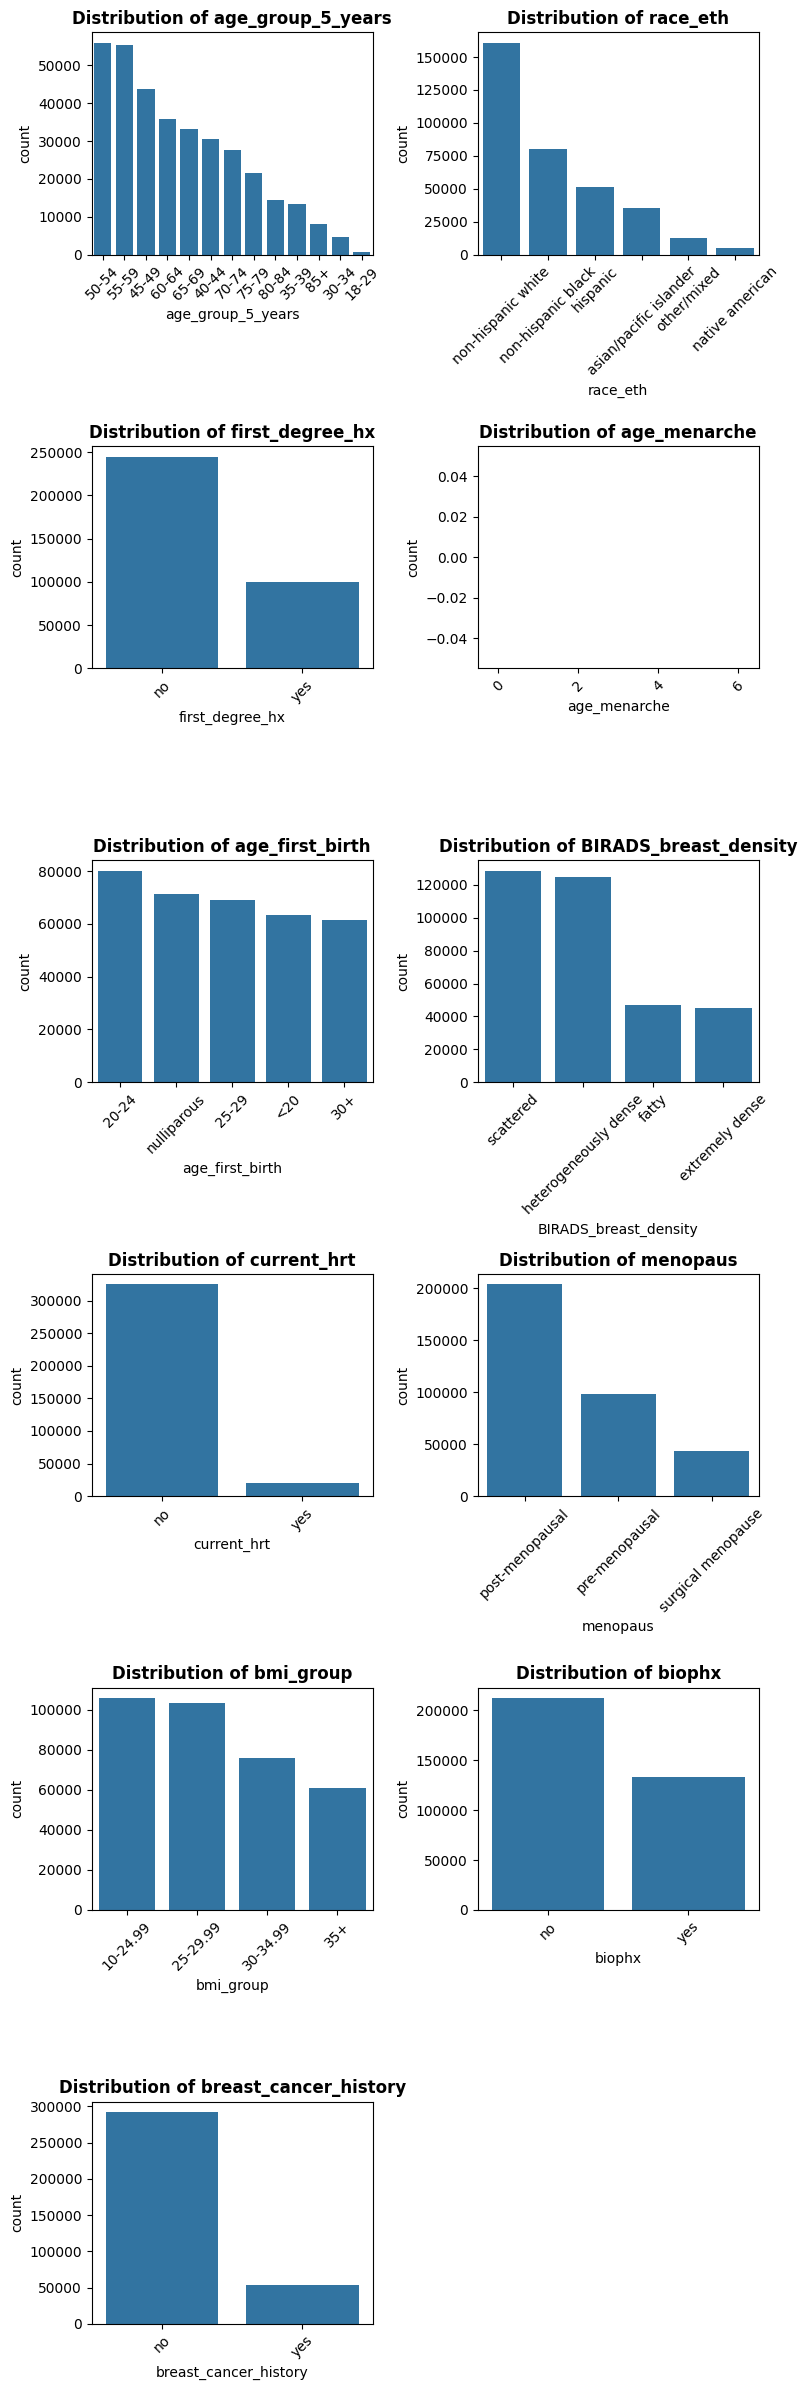

In [ ]:
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_cleaned, x=col, ax=axes[i], order=df_cleaned[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

# Delete empty axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Distribution de base, observer s'il y a des catégories qui dominent ou des déséquilibres (beaucoup de femmes post ménopausées,...)

In [ ]:
#calcul proportion femme avec densité mammaire élevée et proportion femme avec un antécédent de cancer
p_birads_high = (df_cleaned['BIRADS_high'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
p_history = (df_cleaned['breast_cancer_history_bin'] * df_cleaned['count']).sum() / df_cleaned['count'].sum()
print(f'Proportion with high breast density : {p_birads_high:.2%}')
print(f'Proportion with prior breast cancer : {p_history:.2%}')

Proportion with high breast density : 50.89%
Proportion with prior breast cancer : 6.18%


/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
/tmp/ipython-input-4086255362.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col

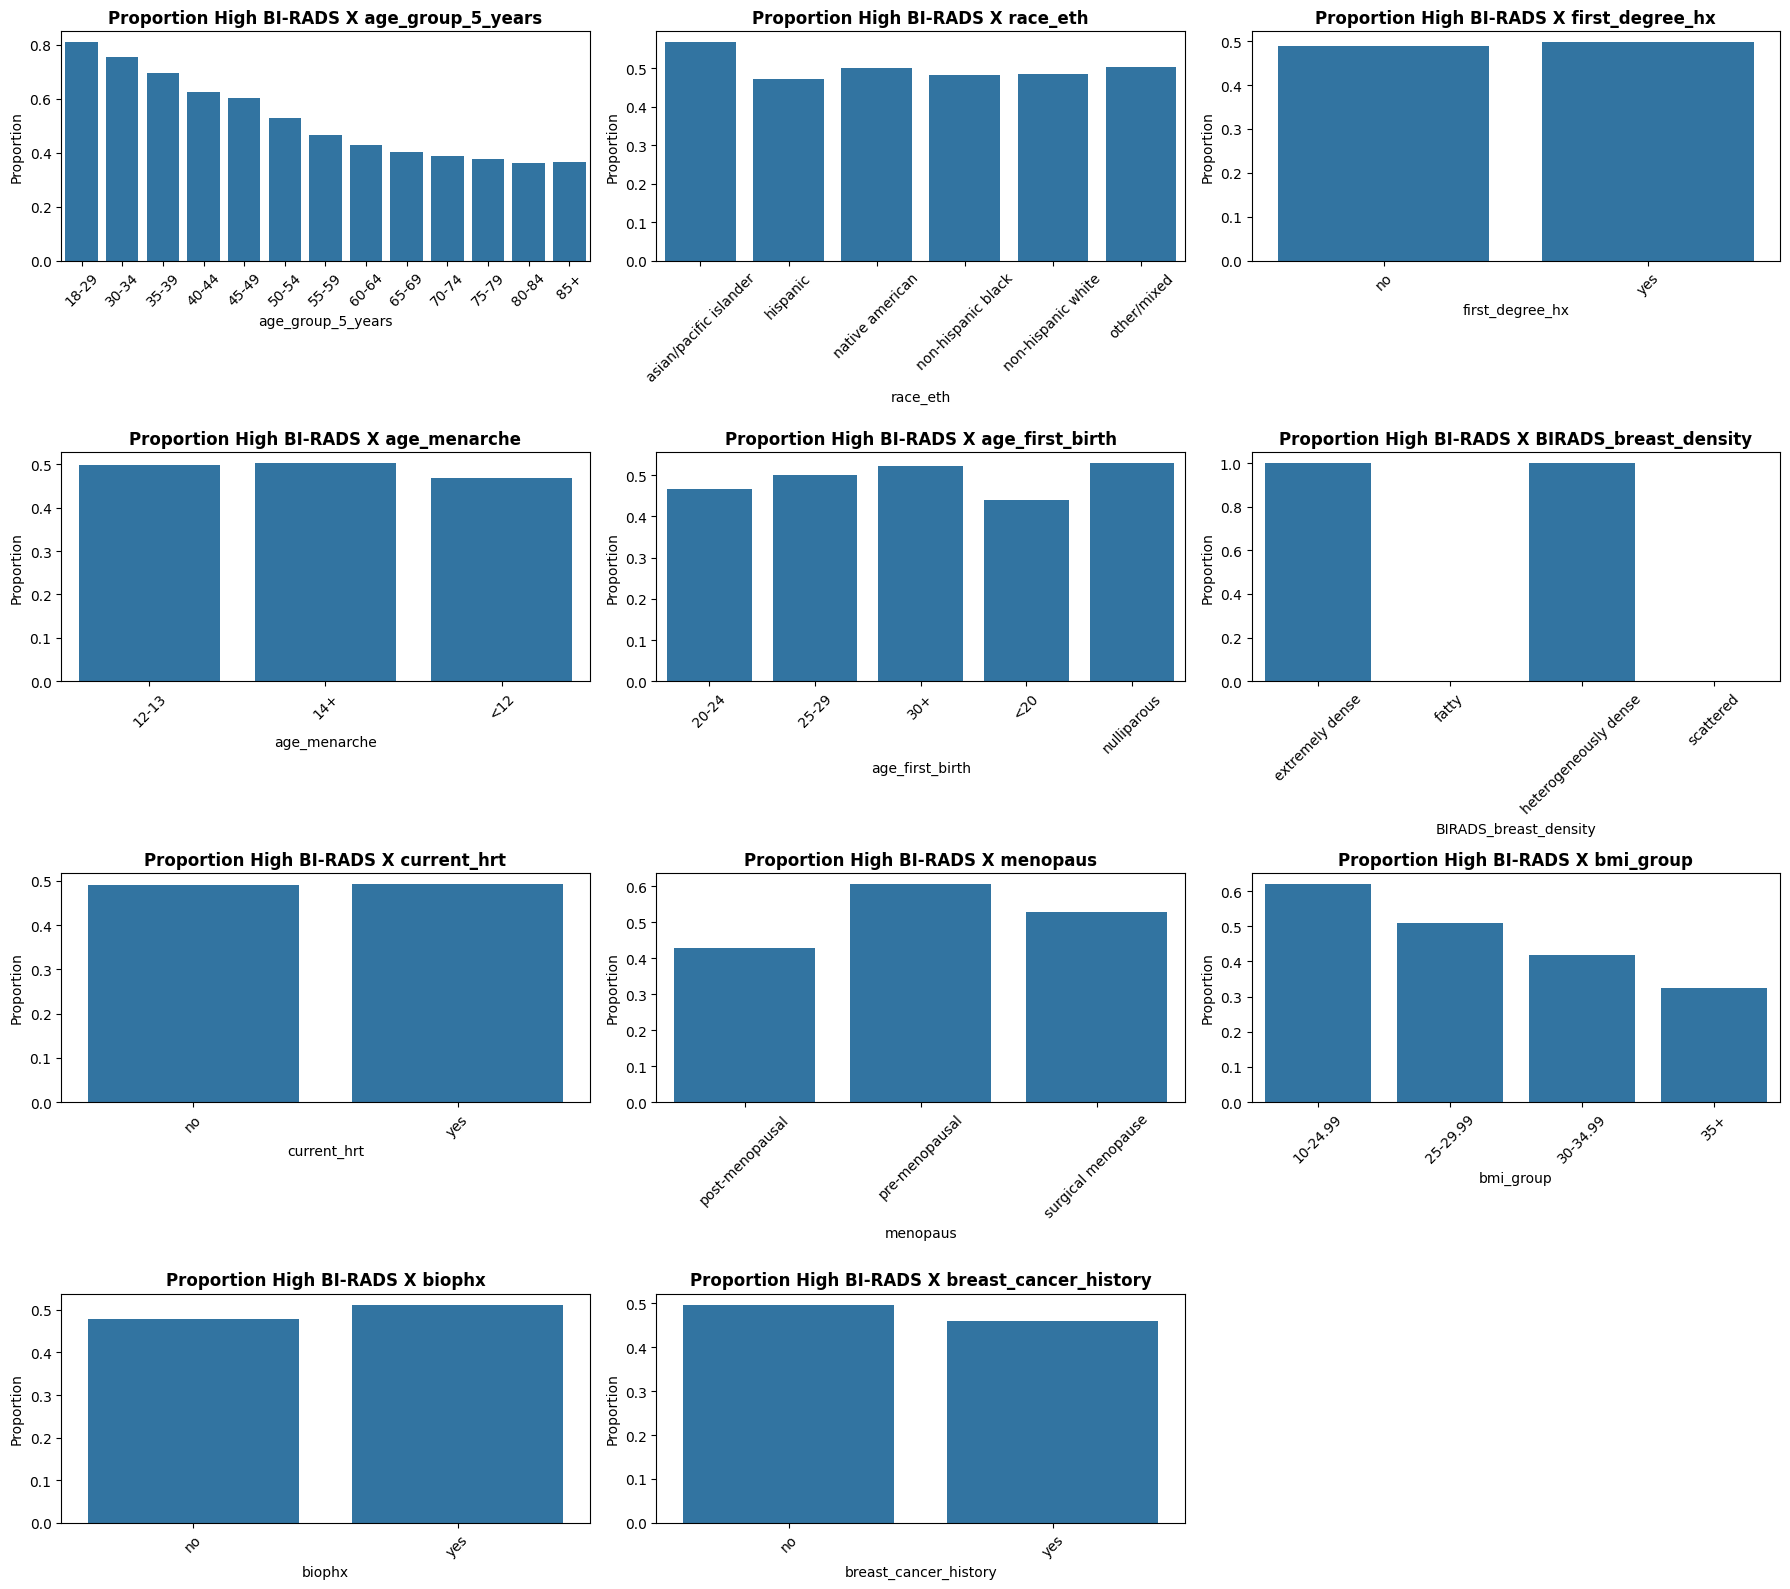

In [ ]:
#Maintenant on veut voir comment les variables explicatives influencent les deux variables cibles (breast_cancer_hisotry et BIRADS_high)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_data = df_cleaned.groupby(col)['BIRADS_high'].mean().reset_index()
    sns.barplot(data=prop_data, x=col, y='BIRADS_high', ax=axes[i])
    axes[i].set_title(f'Proportion High BI-RADS X {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Proportion')

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
/tmp/ipython-input-1726444227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_d

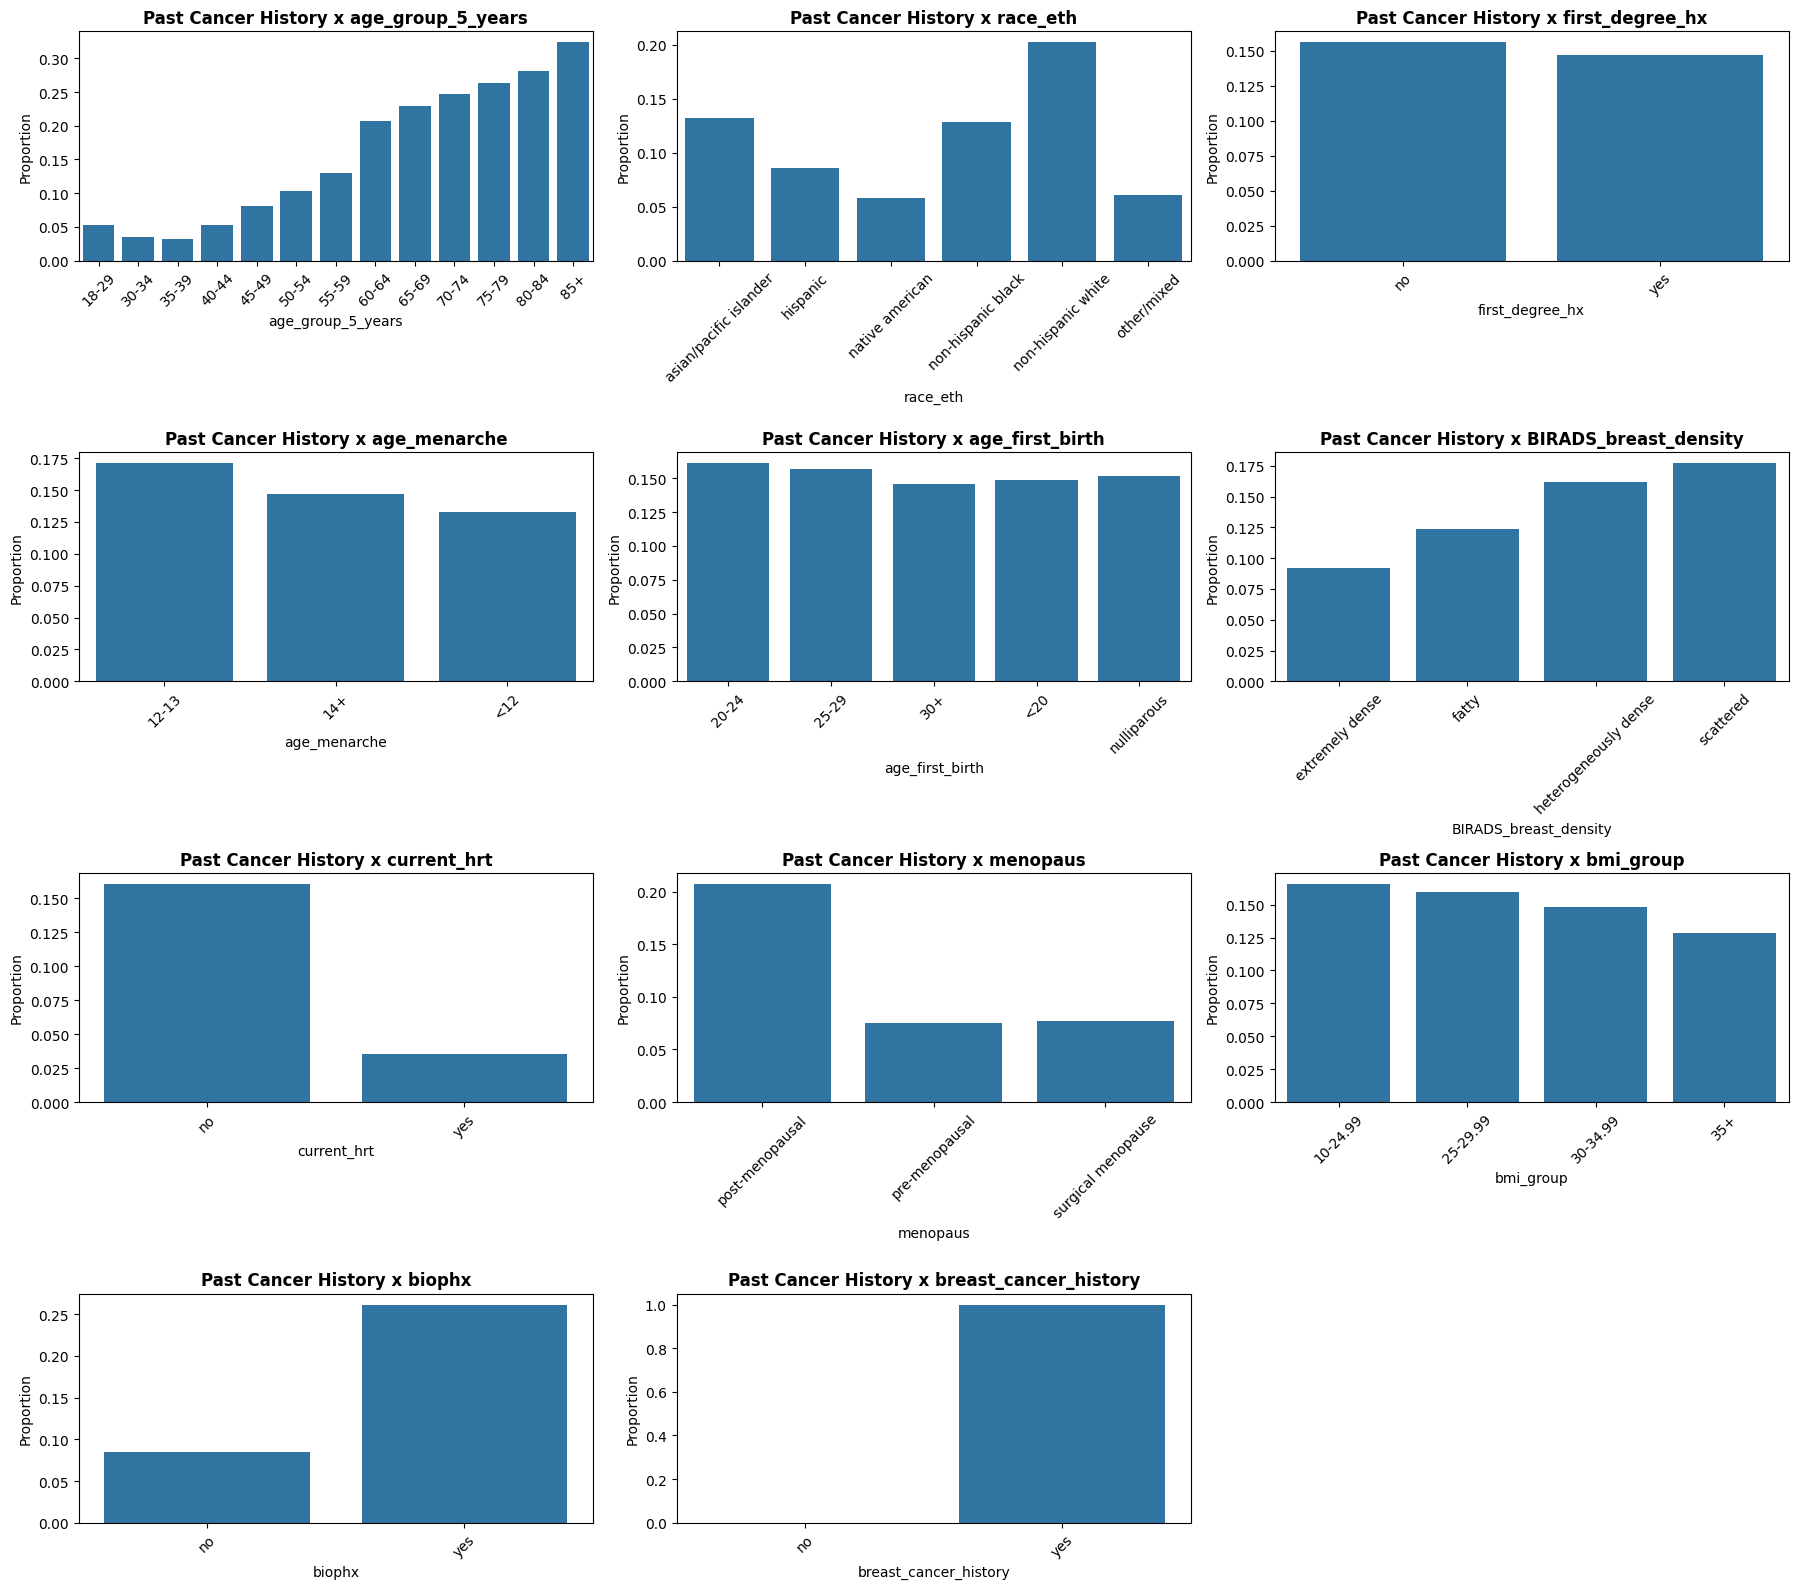

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop_data = df_cleaned.groupby(col)['breast_cancer_history_bin'].mean().reset_index()
    sns.barplot(data=prop_data, x=col, y='breast_cancer_history_bin', ax=axes[i])
    axes[i].set_title(f'Past Cancer History x {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Proportion')

# Supprimer les axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

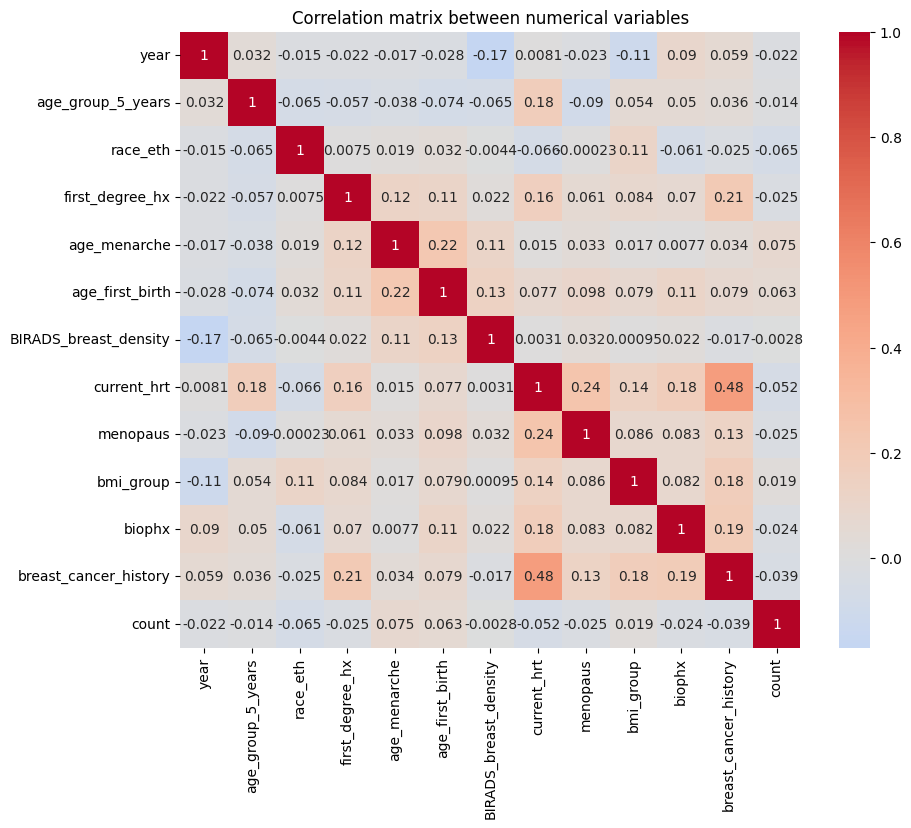

In [ ]:
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix between numerical variables')
plt.show()

Corrélations globalement faibles => pas de multicolinéarité forte entre les variables encodées, donc on peut utiliser ces variables pour faire des régressions

corrélations à noter :

*   current_hrt et menopaus : l'hormonothérapie est liée à la ménopause
*   current_hrt et breast_cancer_history : assez élevé, certaines femmes ayant eu un cancer ont pu suivre un traitement hormonal
*  first_degree_hx et breast_cancer_history : antécédents familiaux corrélés aux antécédents personnels
*   age_menarche et age_first_birth : légère corrélation biologique logique






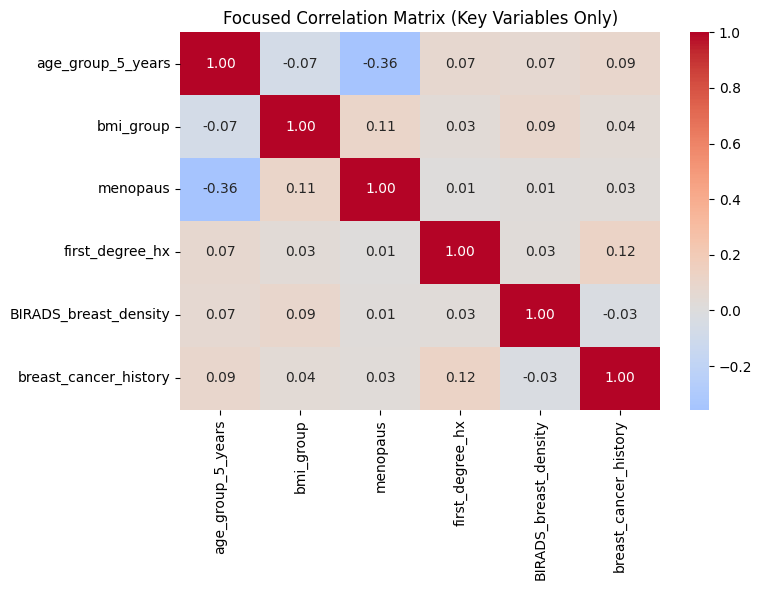

In [ ]:
# Select only the key variables for a focused correlation matrix
cols_focus = [
    "age_group_5_years",
    "bmi_group",
    "menopaus",
    "first_degree_hx",
    "BIRADS_breast_density",
    "breast_cancer_history"
]

# Convert categorical variables to numeric codes for correlation
df_focus = df[cols_focus].apply(lambda x: x.astype("category").cat.codes)

# Compute correlation matrix
corr_focus = df_focus.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_focus, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Focused Correlation Matrix (Key Variables Only)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-4014510157.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["age_code"] = df_cleaned["age_group_5_years"].map(age_order)
/tmp/ipython-input-4014510157.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["bmi_code"] = df_cleaned["bmi_group"].map(bmi_order)
/tmp/ipython-input-4014510157.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

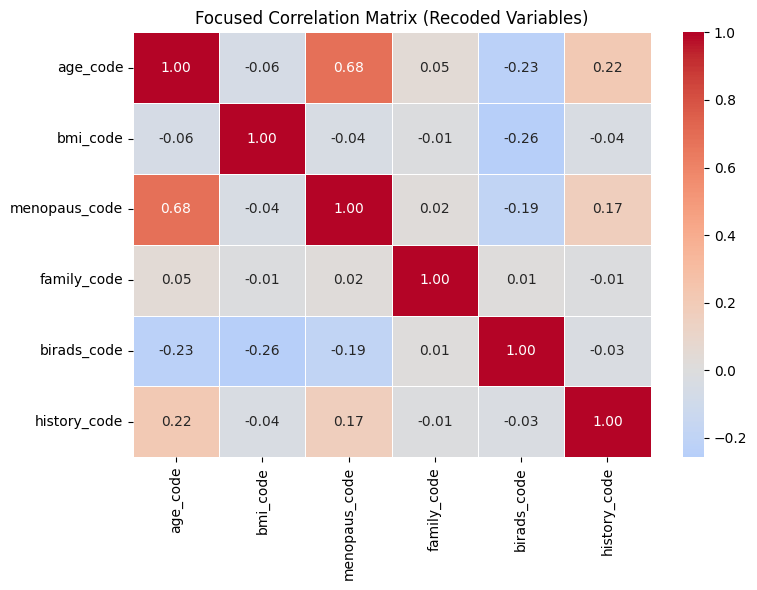

In [ ]:
# -----------------------------------------------
# 1. Recode categories in a meaningful numerical order
# -----------------------------------------------

# Recode age groups in ascending order
age_order = {
    "18-29": 0, "30-34": 1, "35-39": 2, "40-44": 3,
    "45-49": 4, "50-54": 5, "55-59": 6, "60-64": 7,
    "65-69": 8, "70-74": 9, "75-79": 10, "80-84": 11, "85+": 12
}

# Recode BMI categories in ascending BMI
bmi_order = {
    "10-24.99": 0,
    "25-29.99": 1,
    "30-34.99": 2,
    "35+": 3
}

# Recode menopausal status logically: pre → surgical → post
menopause_order = {
    "pre-menopausal": 0,
    "surgical menopause": 1,
    "post-menopausal": 2
}

# Recode family history: no = 0, yes = 1
family_order = {
    "no": 0,
    "yes": 1
}

# Recode BI-RADS density (low → high)
birads_order = {
    "fatty": 0,
    "scattered": 1,
    "heterogeneously dense": 2,
    "extremely dense": 3
}

# Recode prior breast cancer history
history_order = {
    "no": 0,
    "yes": 1
}

# -----------------------------------------------
# 2. Apply recoding to the dataframe
# -----------------------------------------------

df_cleaned["age_code"] = df_cleaned["age_group_5_years"].map(age_order)
df_cleaned["bmi_code"] = df_cleaned["bmi_group"].map(bmi_order)
df_cleaned["menopaus_code"] = df_cleaned["menopaus"].map(menopause_order)
df_cleaned["family_code"] = df_cleaned["first_degree_hx"].map(family_order)
df_cleaned["birads_code"] = df_cleaned["BIRADS_breast_density"].map(birads_order)
df_cleaned["history_code"] = df_cleaned["breast_cancer_history"].map(history_order)

# -----------------------------------------------
# 3. Build the focused correlation dataframe
# -----------------------------------------------

df_corr = df_cleaned[[
    "age_code",
    "bmi_code",
    "menopaus_code",
    "family_code",
    "birads_code",
    "history_code"
]]

# Compute correlation matrix
corr_focus = df_corr.corr()

# -----------------------------------------------
# 4. Plot the focused heatmap
# -----------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_focus,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Focused Correlation Matrix (Recoded Variables)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2004593411.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_BIRADS = df_cleaned.groupby('year').apply(
/tmp/ipython-input-2004593411.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_history = df_cleaned.groupby('year').apply(


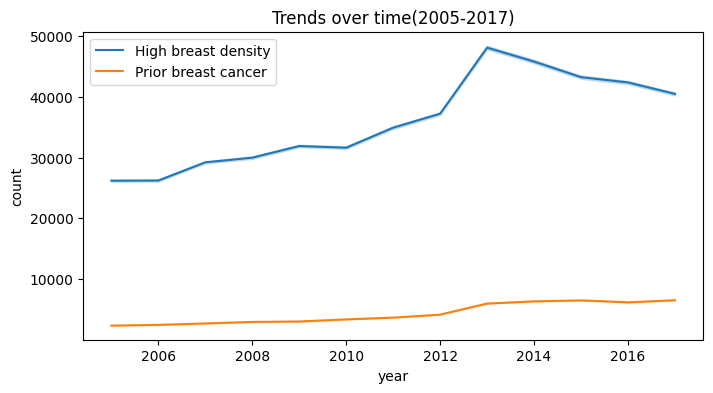

In [ ]:
#voir si il y a des tendances dans le temps
trend_BIRADS = df_cleaned.groupby('year').apply(
    lambda x: (x['BIRADS_high'] * x['count']).sum() / x['count']
).reset_index(name='prop_BIRADS_high')

trend_history = df_cleaned.groupby('year').apply(
    lambda x: (x['breast_cancer_history_bin'] * x['count']).sum() / x['count']
).reset_index(name='prop_history')

plt.figure(figsize=(8,4))
sns.lineplot(data=trend_BIRADS, x='year',y='prop_BIRADS_high', label = 'High breast density')
sns.lineplot(data=trend_history, x='year', y='prop_history', label = 'Prior breast cancer')
plt.title('Trends over time(2005-2017)')
plt.ylabel('count')
plt.legend()
plt.show()

/tmp/ipython-input-867522141.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["high_density"] = df_cleaned["BIRADS_breast_density"].isin(
/tmp/ipython-input-867522141.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["history"] = df_cleaned["breast_cancer_history"].map({"no":0, "yes":1}).fillna(0).astype(int)


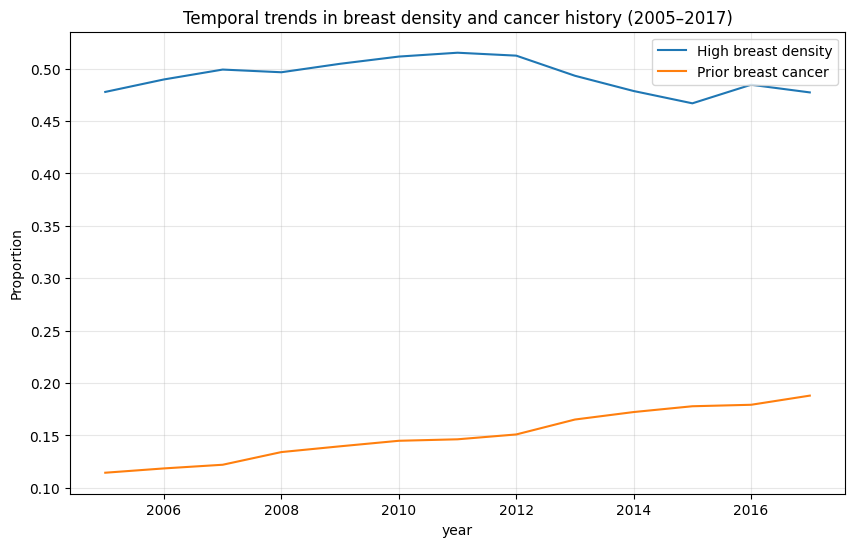

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create binary indicators first
df_cleaned["high_density"] = df_cleaned["BIRADS_breast_density"].isin(
    ["heterogeneously dense", "extremely dense"]
).astype(int)

df_cleaned["history"] = df_cleaned["breast_cancer_history"].map({"no":0, "yes":1}).fillna(0).astype(int)

# Compute proportions per year
temporal = df_cleaned.groupby("year")[["high_density", "history"]].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=temporal, x="year", y="high_density", label="High breast density")
sns.lineplot(data=temporal, x="year", y="history", label="Prior breast cancer")

plt.ylabel("Proportion")
plt.title("Temporal trends in breast density and cancer history (2005–2017)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import statsmodels.api as sm


df_cleaned = df_cleaned.copy().reset_index(drop=True)

#1. age_menarche cleaning
df_cleaned["age_menarche"] = pd.to_numeric(df_cleaned["age_menarche"], errors="coerce")
df_cleaned["age_menarche"] = df_cleaned["age_menarche"].fillna(df_cleaned["age_menarche"].median())

df_cleaned["menarche_group"] = pd.cut(
    df_cleaned["age_menarche"],
    bins=[0, 11, 13, 15, 25],
    labels=["<12", "12–13", "14–15", "16+"],
    include_lowest=True
)

#2. Variable Y
y_density = (
    df_cleaned["BIRADS_breast_density"]
    .isin(["heterogeneously dense", "extremely dense"])
).astype(int)

#3. Explicative variables
X_density = df_cleaned[[
    "age_group_5_years",
    "bmi_group",
    "menopaus",
    "age_first_birth",
    "menarche_group"
]]

#Dummies
X_density = pd.get_dummies(X_density, drop_first=True)

#4. Cleaning NaN
X_density = X_density.replace([float("inf"), -float("inf")], float("nan"))
X_density = X_density.dropna()
y_density = y_density.loc[X_density.index]

# 5. suppression of the columns that are constant
for col in X_density.columns:
    if X_density[col].nunique() <= 1:
        print("Deleted columns (constant) :", col)
        X_density = X_density.drop(columns=[col])


#suppression of columns that are perfectly colinear

X_density = X_density.loc[:, ~X_density.columns.duplicated()]


#6. Conversion + constant
X_density = sm.add_constant(X_density.astype(float))

#7. logistic regression
model_density = sm.Logit(y_density, X_density).fit(disp=False)

# 8. Construction d'une table de résultats
coef = model_density.params
bse = model_density.bse
pvalues = model_density.pvalues
conf = model_density.conf_int()
conf.columns = ["CI 2.5%", "CI 97.5%"]

regression_table = pd.DataFrame({
    "Variable": coef.index,
    "Coefficient": coef.to_numpy(),
    "Std. Error": bse.to_numpy(),
    "p-value": pvalues.to_numpy(),
    "OR": np.exp(coef.to_numpy()),
    "OR 2.5%": np.exp(conf["CI 2.5%"].to_numpy()),
    "OR 97.5%": np.exp(conf["CI 97.5%"].to_numpy()),
})

regression_table = (
    regression_table
    .assign(
        Coefficient=lambda d: d["Coefficient"].round(3),
        **{"Std. Error": lambda d: d["Std. Error"].round(3)},
        **{"p-value": lambda d: d["p-value"].round(3)},
        OR=lambda d: d["OR"].round(2),
        **{"OR 2.5%": lambda d: d["OR 2.5%"].round(2)},
        **{"OR 97.5%": lambda d: d["OR 97.5%"].round(2)},
    )
)

regression_table

Deleted columns (constant) : menarche_group_12–13
Deleted columns (constant) : menarche_group_14–15
Deleted columns (constant) : menarche_group_16+


,Variable,Coefficient,Std. Error,p-value,OR,OR 2.5%,OR 97.5%
0,const,1.752,0.093,0.000,5.77,4.81,6.92
1,age_group_5_years_30-34,-0.244,0.098,0.013,0.78,0.65,0.95
2,age_group_5_years_35-39,-0.514,0.094,0.000,0.60,0.50,0.72
3,age_group_5_years_40-44,-0.810,0.093,0.000,0.44,0.37,0.53
4,age_group_5_years_45-49,-0.898,0.092,0.000,0.41,0.34,0.49
5,age_group_5_years_50-54,-1.190,0.092,0.000,0.30,0.25,0.36
6,age_group_5_years_55-59,-1.418,0.092,0.000,0.24,0.20,0.29
7,age_group_5_years_60-64,-1.530,0.093,0.000,0.22,0.18,0.26
8,age_group_5_years_65-69,-1.642,0.093,0.000,0.19,0.16,0.23
9,age_group_5_years_70-74,-1.727,0.093,0.000,0.18,0.15,0.21


 Interprétation complète du Modèle A : Régression logistique sur la densité mammaire

Le Modèle A vise à identifier les facteurs associés à une forte densité mammaire (BI-RADS 3–4) à partir d’une régression logistique multivariée. Les variables incluses sont l’âge, le BMI, le statut ménopausique ainsi que des indicateurs de l’histoire reproductive. L’objectif est de quantifier l’effet propre de chaque facteur tout en contrôlant les autres, afin d’évaluer leur contribution réelle au risque de présenter une densité élevée.

⸻

1. Effet de l’âge : le déterminant dominant

Les résultats montrent que l’âge est de loin le facteur le plus fortement associé à la densité mammaire. Les coefficients deviennent de plus en plus négatifs avec l’avancée en âge, indiquant une diminution très marquée de la probabilité d’avoir des seins denses à mesure que les femmes vieillissent.

Comparées aux femmes de 18–29 ans, toutes les classes d’âge supérieures présentent des odds significativement plus faibles de densité élevée, avec un déclin particulièrement abrupt après 50 ans (ex : coef = −0.40 pour 50–54 ans, −0.65 pour 60–64 ans, −0.94 pour 85+).

Interprétation : ce résultat traduit l’involution progressive du tissu glandulaire post-ménopause, phénomène bien documenté en épidémiologie du cancer du sein. Il confirme également les tendances observées dans l’EDA, où la proportion de seins denses chutait nettement avec l’âge.

⸻

2. BMI : une association inverse forte et cohérente

Le BMI apparaît comme un second facteur majeur. Les coefficients sont systématiquement négatifs et deviennent plus importants à mesure que le BMI augmente. Les femmes obèses (BMI ≥ 35) présentent presque un log-odds de −1, ce qui correspond à une réduction massive de la probabilité de densité élevée par rapport aux femmes de poids normal.

Interprétation : ce résultat s’explique par une proportion plus importante de tissu adipeux chez les femmes à BMI élevé, rendant les seins moins denses sur les mammographies. Ce gradient inverse était également très visible dans l’EDA.

⸻

3. Statut ménopausique : un rôle hormonal net mais secondaire

Le statut ménopausique exerce aussi une influence significative. Les femmes pré-ménopausées présentent des odds plus élevées de forte densité (coef = +0.23) que les femmes post-ménopausées (catégorie de référence). Les femmes avec ménopause chirurgicale montrent un effet similaire (+0.19).

Interprétation : ces résultats reflètent la dépendance hormonale de la densité mammaire. Avant la ménopause, l’activité oestrogénique est plus élevée, ce qui se traduit par une proportion plus importante de tissu fibroglandulaire.

⸻

4. Facteurs reproductifs : effets modestes mais significatifs

Âge à la première naissance
	•	Avoir sa première grossesse tardivement (30+ : coef = +0.36 ; 25–29 ans : +0.19)
	•	Être nullipare (+0.18)
	•	Avoir accouché très jeune (<20 ans : −0.10)

Interprétation : un accouchement tardif ou l’absence de grossesse sont connus pour être associés à une exposition hormonale prolongée, ce qui peut favoriser une plus grande densité. À l’inverse, une grossesse très précoce semble exercer un effet protecteur.

Âge des premières règles

Les associations sont significatives mais plus faibles (ex : âge des premières règles 30–34 ans : coef = −0.14).

Interprétation : l’âge des premières règles est un indicateur d’exposition hormonale cumulée, mais son impact sur la densité est moins marqué que les autres déterminants.

⸻

5. Synthèse

Le modèle met clairement en évidence trois conclusions majeures :
	1.	La densité mammaire est principalement déterminée par l’âge et le BMI, deux facteurs dont l’effet est à la fois statistiquement très significatif et cliniquement cohérent.
	2.	Le statut hormonal (ménopause) joue un rôle secondaire mais robuste, confirmant l’importance des variations oestrogéniques.
	3.	Les facteurs reproductifs contribuent également, bien que de manière plus modérée, à expliquer la variabilité de la densité mammaire.

Ces résultats confirment largement les observations issues de l’EDA, tout en quantifiant précisément l’ampleur des effets. Ils fournissent une base solide pour comprendre les profils de femmes à risque de forte densité mammaire, un facteur important pour le dépistage et la prévention du cancer du sein.


In [ ]:
# 1. Cleaning of the dependent variable
df_cleaned["breast_cancer_history"] = (
    df_cleaned["breast_cancer_history"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Recode : yes = 1, no = 0, NaN = 0
y_history = df_cleaned["breast_cancer_history"].map({
    "yes": 1,
    "no": 0
}).fillna(0).astype(float)

print("Repartition of y_history :")
print(y_history.value_counts())

# 2. Construction of X (same predictors as in Regression A)
predictors_B = [
    "age_group_5_years",
    "bmi_group",
    "menopaus",
    "first_degree_hx",
    "age_first_birth",
    "menarche_group"
]

#Dummies
X_history = pd.get_dummies(df_cleaned[predictors_B], drop_first=True)

# Add constant and align with y
X_history = sm.add_constant(X_history)
X_history = X_history.loc[y_history.index]

# Conversion in float
X_history = X_history.astype(float)

# 3. Deleting problematic columns

# A. quasi constant columns (0 or 1 unique)
low_var_cols = [col for col in X_history.columns if X_history[col].nunique() <= 1]
print("Quasi-constant columns deleted :", low_var_cols)
X_history = X_history.drop(columns=low_var_cols, errors="ignore")

# B. Perfectly colinear columns
corr_matrix = X_history.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear = [col for col in upper.columns if any(upper[col] == 1)]
print("Colinear columns deleted :", collinear)
X_history = X_history.drop(columns=collinear, errors="ignore")

# C. Perfect separation (no 1 in a category among y=1)
perfect_sep_cols = []
for col in X_history.columns:
    if col == "const":
        continue
    if (X_history[col][y_history == 1] == 1).sum() == 0:
        perfect_sep_cols.append(col)

print("Columns causing perfect separation deleted :", perfect_sep_cols)
X_history = X_history.drop(columns=perfect_sep_cols, errors="ignore")

# 4. Final model
print("\nFinal dimensions X :", X_history.shape)

# Logistic regression
model_history = sm.Logit(y_history, X_history).fit(disp=False)

# 5. Build a nice result table
coef = model_history.params
bse = model_history.bse
pvalues = model_history.pvalues
conf = model_history.conf_int()
conf.columns = ["CI 2.5%", "CI 97.5%"]

regression_history_table = pd.DataFrame({
    "Variable": coef.index,
    "Coefficient": coef.to_numpy(),
    "Std. Error": bse.to_numpy(),
    "p-value": pvalues.to_numpy(),
    "OR": np.exp(coef.to_numpy()),
    "OR 2.5%": np.exp(conf["CI 2.5%"].to_numpy()),
    "OR 97.5%": np.exp(conf["CI 97.5%"].to_numpy()),
})

regression_history_table = (
    regression_history_table
    .assign(
        Coefficient=lambda d: d["Coefficient"].round(3),
        **{"Std. Error": lambda d: d["Std. Error"].round(3)},
        **{"p-value": lambda d: d["p-value"].round(3)},
        OR=lambda d: d["OR"].round(2),
        **{"OR 2.5%": lambda d: d["OR 2.5%"].round(2)},
        **{"OR 97.5%": lambda d: d["OR 97.5%"].round(2)},
    )
)

regression_history_table

Repartition of y_history :
breast_cancer_history
0.0    292132
1.0     52932
Name: count, dtype: int64
Quasi-constant columns deleted : ['const', 'menarche_group_12–13', 'menarche_group_14–15', 'menarche_group_16+']
Colinear columns deleted : []
Columns causing perfect separation deleted : []

Final dimensions X : (345064, 22)


,Variable,Coefficient,Std. Error,p-value,OR,OR 2.5%,OR 97.5%
0,age_group_5_years_30-34,-2.877,0.083,0.000,0.06,0.05,0.07
1,age_group_5_years_35-39,-2.941,0.053,0.000,0.05,0.05,0.06
2,age_group_5_years_40-44,-2.442,0.032,0.000,0.09,0.08,0.09
3,age_group_5_years_45-49,-2.006,0.024,0.000,0.13,0.13,0.14
4,age_group_5_years_50-54,-1.801,0.020,0.000,0.17,0.16,0.17
5,age_group_5_years_55-59,-1.572,0.018,0.000,0.21,0.20,0.22
6,age_group_5_years_60-64,-1.192,0.018,0.000,0.30,0.29,0.31
7,age_group_5_years_65-69,-1.063,0.018,0.000,0.35,0.33,0.36
8,age_group_5_years_70-74,-0.965,0.018,0.000,0.38,0.37,0.39
9,age_group_5_years_75-79,-0.886,0.019,0.000,0.41,0.40,0.43
